In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
# ============================================================================
# 0. CUSTOM METRICS
# ============================================================================

def compute_metrics(y_true, y_pred, label=""):
    """
    Compute comprehensive evaluation metrics:
    R², RMSE, MAE, MBE, NMB, Pearson r, MAPE, IOA
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # Mean Bias Error (positive = model over-predicts)
    mbe  = np.mean(y_pred - y_true)

    # Normalised Mean Bias  (MBE / mean_observed)
    nmb  = mbe / np.mean(y_true) if np.mean(y_true) != 0 else np.nan

    # Pearson correlation
    r_val, p_val = pearsonr(y_true, y_pred)

    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

    # Index of Agreement (Willmott 1981)
    num   = np.sum((y_true - y_pred) ** 2)
    denom = np.sum((np.abs(y_pred - np.mean(y_true)) +
                    np.abs(y_true - np.mean(y_true))) ** 2)
    ioa   = 1 - num / denom if denom != 0 else np.nan

    metrics = dict(
        R2=r2, RMSE=rmse, MAE=mae,
        MBE=mbe, NMB=nmb,
        Pearson_r=r_val, MAPE=mape, IOA=ioa
    )

    if label:
        print(f"\n{'─'*60}")
        print(f"  METRICS: {label}")
        print(f"{'─'*60}")
        print(f"  R²          : {r2:.4f}")
        print(f"  RMSE        : {rmse:.4f} µg/m³")
        print(f"  MAE         : {mae:.4f} µg/m³")
        print(f"  MBE         : {mbe:.4f} µg/m³  (+ = over-predict)")
        print(f"  NMB         : {nmb:.4f}         (fraction)")
        print(f"  Pearson r   : {r_val:.4f}  (p={p_val:.2e})")
        print(f"  MAPE        : {mape:.2f} %")
        print(f"  IOA         : {ioa:.4f}")

    return metrics


def compute_spatial_r2(df_test_with_meta, y_pred, station_col='station'):
    """
    Spatial R²: per-station mean observed vs per-station mean predicted.
    Measures whether the model captures the spatial gradient.
    """
    tmp = df_test_with_meta[['groundtruth_no2', station_col]].copy()
    tmp['y_pred'] = y_pred

    agg = tmp.groupby(station_col).agg(
        obs_mean=('groundtruth_no2', 'mean'),
        pred_mean=('y_pred', 'mean')
    )

    spatial_r2 = r2_score(agg['obs_mean'], agg['pred_mean'])
    r_val, _ = pearsonr(agg['obs_mean'], agg['pred_mean'])

    print(f"\n  Spatial R²  : {spatial_r2:.4f}  (n_stations={len(agg)})")
    print(f"  Spatial r   : {r_val:.4f}")
    return spatial_r2, r_val


def compute_temporal_r2(df_test_with_meta, y_pred, date_col='date'):
    """
    Temporal R²: per-day mean observed vs per-day mean predicted.
    Measures whether the model captures the temporal trend.
    """
    tmp = df_test_with_meta[['groundtruth_no2', date_col]].copy()
    tmp['y_pred'] = y_pred

    agg = tmp.groupby(date_col).agg(
        obs_mean=('groundtruth_no2', 'mean'),
        pred_mean=('y_pred', 'mean')
    )

    temporal_r2 = r2_score(agg['obs_mean'], agg['pred_mean'])
    r_val, _ = pearsonr(agg['obs_mean'], agg['pred_mean'])

    print(f"  Temporal R² : {temporal_r2:.4f}  (n_days={len(agg)})")
    print(f"  Temporal r  : {r_val:.4f}")
    return temporal_r2, r_val

In [ ]:
# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

def load_and_preprocess_data(filepath):
    """
    Load and preprocess the master dataset
    """
    print("\n" + "=" * 80)
    print("STEP 1: LOADING DATA")
    print("=" * 80)

    df = pd.read_csv(filepath)
    print(f"✓ Data loaded successfully")
    print(f"  - Rows: {df.shape[0]:,}")
    print(f"  - Columns: {df.shape[1]}")
    print(f"  - Stations: {df['station'].nunique()}")

    df['date'] = pd.to_datetime(df['date'])
    print(f"✓ Date converted to datetime")
    print(f"  - Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"  - Total days: {(df['date'].max() - df['date'].min()).days}")

    print("\n✓ Sample of your data:")
    print(df.head(3).to_string())

    print("\n" + "-" * 80)
    print("DATA QUALITY CHECK")
    print("-" * 80)
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print("Missing values found:")
        for col in missing[missing > 0].index:
            pct = (missing[col] / len(df)) * 100
            print(f"  - {col}: {missing[col]:,} ({pct:.1f}%)")
    else:
        print("✓ No missing values found!")

    return df

In [ ]:
# ============================================================================
# 2. MISSING VALUE HANDLING  ── ML-based gap filling (no mean imputation)
# ============================================================================

def handle_missing_values(df):
    """
    Handle missing values in the dataset.

    Strategy for tropospheric_no2 (satellite gaps due to clouds):
    ─────────────────────────────────────────────────────────────
    1.  Add `satellite_missing_flag` = 1 where NO₂ is NaN.
    2.  Build a small auxiliary Ridge regression trained ONLY on rows
        where tropospheric_no2 is observed (flag = 0).
    3.  Use the auxiliary model to PREDICT the missing rows.
    4.  Replace ONLY those missing rows with the ML prediction.
        → True gap reconstruction; no mean-based imputation.
    """
    print("\n" + "=" * 80)
    print("STEP 2: HANDLING MISSING VALUES  (ML-based gap filling)")
    print("=" * 80)

    initial_rows = len(df)

    # ── Remove rows where target is missing ──────────────────────────────────
    df = df.dropna(subset=['groundtruth_no2'])
    removed = initial_rows - len(df)
    if removed > 0:
        print(f"✓ Removed {removed:,} rows with missing groundtruth_no2")
    else:
        print("✓ No missing values in groundtruth_no2")

    # ── satellite_missing_flag ───────────────────────────────────────────────
    df['satellite_missing_flag'] = df['tropospheric_no2'].isnull().astype(int)
    missing_count = df['satellite_missing_flag'].sum()

    if missing_count > 0:
        print(f"\n✓ {missing_count:,} rows have missing tropospheric_no2 (cloudy days)")
        print("  → Training auxiliary Ridge model to reconstruct gaps …")

        gap_proxy_cols = [
            c for c in df.columns
            if c not in ['station', 'date', 'groundtruth_no2',
                         'tropospheric_no2', 'satellite_missing_flag']
            and df[c].dtype in [np.float64, np.float32, np.int64, np.int32, int, float]
        ]

        obs_mask = df['satellite_missing_flag'] == 0
        gap_mask = df['satellite_missing_flag'] == 1

        valid_proxy = [
            c for c in gap_proxy_cols
            if df.loc[obs_mask, c].isnull().sum() == 0
            and df.loc[gap_mask, c].isnull().sum() == 0
        ]

        if not valid_proxy:
            valid_proxy = gap_proxy_cols

        X_obs = df.loc[obs_mask, valid_proxy].copy()
        y_obs = df.loc[obs_mask, 'tropospheric_no2'].copy()
        X_gap = df.loc[gap_mask, valid_proxy].copy()

        aux_model = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('ridge',   Ridge(alpha=1.0))
        ])
        aux_model.fit(X_obs, y_obs)

        gap_preds = aux_model.predict(X_gap)
        gap_preds = np.clip(gap_preds, 0, None)

        df.loc[gap_mask, 'tropospheric_no2'] = gap_preds

        aux_r2 = r2_score(y_obs, aux_model.predict(X_obs))
        print(f"  ✓ Auxiliary model train R² = {aux_r2:.3f}")
        print(f"  ✓ Replaced {missing_count:,} missing satellite values with ML predictions")
    else:
        print("✓ No missing satellite data")

    # ── Any remaining NaN in other predictors ────────────────────────────────
    predictor_cols = [col for col in df.columns
                      if col not in ['station', 'date', 'groundtruth_no2']]
    remaining_missing = df[predictor_cols].isnull().sum().sum()
    if remaining_missing > 0:
        print(f"\n⚠ Warning: {remaining_missing} missing values in other features")
        print("  - Filling with column means (last resort) …")
        df[predictor_cols] = df[predictor_cols].fillna(df[predictor_cols].mean())
        print("  ✓ Done")

    print(f"\n✓ Final dataset: {len(df):,} rows ready for modeling")
    return df

In [ ]:
# ============================================================================
# 3. FEATURE ENGINEERING  (WITH LAG FEATURES + spatial neighbor)
# ============================================================================

def create_features(df):
    """
    Create additional features.
    ─ Lag / moving-average features: INCLUDED (no2_lag1, no2_lag7, no2_ma3, no2_ma7)
    ─ Spatial neighbor feature (spatial_lag_no2): INCLUDED
    """
    print("\n" + "=" * 80)
    print("STEP 3: FEATURE ENGINEERING")
    print("=" * 80)

    initial_features = len(df.columns)

    # ── 1. TEMPORAL FEATURES ─────────────────────────────────────────────────
    print("\n1. Creating temporal features …")
    df['year']               = df['date'].dt.year
    df['month']              = df['date'].dt.month
    df['day']                = df['date'].dt.day
    df['day_of_year']        = df['date'].dt.dayofyear
    df['day_of_week']        = df['date'].dt.dayofweek
    df['is_weekend']         = (df['day_of_week'] >= 5).astype(int)

    df['season'] = df['month'].apply(lambda x:
        'winter' if x in [12, 1, 2] else
        'spring' if x in [3, 4, 5] else
        'summer' if x in [6, 7, 8] else
        'autumn')
    season_map = {'winter': 1, 'spring': 2, 'summer': 3, 'autumn': 4}
    df['season_numeric']     = df['season'].map(season_map)

    df['is_critical_winter'] = df['month'].apply(lambda x: 1 if x in [11, 12, 1, 2] else 0)
    print("   ✓ Added 8 temporal features")

    # ── 2. METEOROLOGICAL FEATURES ───────────────────────────────────────────
    print("\n2. Creating meteorological features …")
    df['wind_direction']   = (np.degrees(np.arctan2(df['v10'], df['u10'])) + 360) % 360
    df['stability_index']  = df['BLH'] / (df['wind_speed'] + 0.1)
    df['ventilation_coef'] = df['BLH'] * df['wind_speed']
    df['temp_category'] = pd.cut(df['temperature_2m_C'],
                                  bins=[-np.inf, 15, 25, np.inf],
                                  labels=['cold', 'moderate', 'hot'])
    df['is_cold'] = (df['temperature_2m_C'] < 15).astype(int)
    df['is_hot']  = (df['temperature_2m_C'] > 30).astype(int)
    print("   ✓ Added 7 meteorological features")

    # ── 3. EMISSION PROXY FEATURES ───────────────────────────────────────────
    print("\n3. Creating emission proxy features …")
    df['urban_intensity']     = df['population_density'] * df['night_light']
    df['urban_intensity_log'] = np.log1p(df['urban_intensity'])
    print("   ✓ Added 2 emission proxy features")

    # ── 4. SPATIAL FEATURES ──────────────────────────────────────────────────
    print("\n4. Creating spatial features …")
    delhi_center_lat, delhi_center_lon = 28.6139, 77.2090
    df['dist_from_center'] = np.sqrt(
        (df['lat'] - delhi_center_lat) ** 2 +
        (df['lon'] - delhi_center_lon) ** 2
    ) * 111
    print("   ✓ Added 1 distance feature")

    # ── 5. TEMPORAL LAG FEATURES ─────────────────────────────────────────────
    print("\n5. Creating temporal lag features …")
    df = df.sort_values(['station', 'date'])

    # Yesterday's NO2 (very predictive)
    df['no2_lag1'] = df.groupby('station')['groundtruth_no2'].shift(1)

    # Last week's NO2
    df['no2_lag7'] = df.groupby('station')['groundtruth_no2'].shift(7)

    # 3-day moving average
    df['no2_ma3'] = df.groupby('station')['groundtruth_no2'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )

    # 7-day moving average
    df['no2_ma7'] = df.groupby('station')['groundtruth_no2'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    )
    print("   ✓ Added 4 lag features: no2_lag1, no2_lag7, no2_ma3, no2_ma7")

    # ── 6. SPATIAL NEIGHBOR FEATURE (spatial_lag_no2) ─────────────────────────
    print("\n6. Creating spatial neighbor feature (spatio-temporal) …")
    print("   Computing mean tropospheric_no2 of adjacent stations on the same day …")

    df = df.sort_values(['date', 'station']).reset_index(drop=True)

    df['_lat_r'] = df['lat'].round(2)
    df['_lon_r'] = df['lon'].round(2)

    spatial_lag_vals = []
    station_coords = df[['station', 'lat', 'lon']].drop_duplicates().set_index('station')
    daily_station  = df.groupby(['date', 'station'])['tropospheric_no2'].mean()

    for idx, row in df.iterrows():
        target_lat  = row['lat']
        target_lon  = row['lon']
        target_date = row['date']
        target_sta  = row['station']

        dist = np.sqrt(
            (station_coords['lat'] - target_lat) ** 2 +
            (station_coords['lon'] - target_lon) ** 2
        )
        neighbours = dist[(dist <= 0.10) & (dist.index != target_sta)].index.tolist()

        if neighbours:
            vals = []
            for n in neighbours:
                key = (target_date, n)
                if key in daily_station.index:
                    vals.append(daily_station[key])
            spatial_lag_vals.append(np.mean(vals) if vals else np.nan)
        else:
            spatial_lag_vals.append(np.nan)

    df['spatial_lag_no2'] = spatial_lag_vals

    df['spatial_lag_no2'] = df.groupby('station')['spatial_lag_no2'].transform(
        lambda x: x.fillna(x.mean())
    )
    df['spatial_lag_no2'] = df['spatial_lag_no2'].fillna(df['tropospheric_no2'])

    df.drop(columns=['_lat_r', '_lon_r'], inplace=True)
    print("   ✓ Added 1 spatial_lag_no2 feature  (true spatio-temporal signal)")

    # ── 7. INTERACTION FEATURES ──────────────────────────────────────────────
    print("\n7. Creating interaction features …")
    df['satellite_stability']    = df['tropospheric_no2'] * df['stability_index']
    df['cloud_temp_interaction'] = df['total_cloud_cover'] * (1 / (df['temperature_2m_C'] + 1))
    print("   ✓ Added 2 interaction features")

    final_features = len(df.columns)
    print("\n" + "-" * 80)
    print(f"✓ FEATURE ENGINEERING COMPLETE")
    print(f"  - Started with: {initial_features} columns")
    print(f"  - Created: {final_features - initial_features} new features")
    print(f"  - Total features: {final_features} columns")
    print("  ✓ Lag / moving-average features: INCLUDED (no2_lag1, no2_lag7, no2_ma3, no2_ma7)")
    print("  ✓ spatial_lag_no2: INCLUDED (mean NO2 of ≤11 km neighbours, same day)")
    print("-" * 80)

    return df

In [ ]:
# ============================================================================
# 4. DATA PREPARATION  (temporal + spatial split; drop NaN from lag features)
# ============================================================================

def prepare_train_test_split(df, random_state=42):
    """
    Temporal + Spatial validation split.
    Train: Mar–Nov (non-winter); Test: Dec–Feb + 5 held-out stations.
    NaN rows from lag features are dropped before splitting.
    """
    print("\n" + "=" * 80)
    print("STEP 4: PREPARING TRAIN-TEST SPLIT")
    print("=" * 80)
    print("\n⚠️  ADVANCED VALIDATION STRATEGY:")
    print("   1. TEMPORAL SPLIT: Train on Mar-Nov, Test on Dec-Feb (winter)")
    print("   2. SPATIAL SPLIT : 5 stations held out for testing")
    print("=" * 80)

    exclude_cols = [
        'station', 'date', 'groundtruth_no2',
        'season', 'temp_category'
    ]
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    print(f"\n✓ Selected {len(feature_cols)} features for modeling")

    temporal_features  = [f for f in feature_cols if any(x in f for x in ['year','month','day','season','weekend','winter'])]
    meteo_features     = [f for f in feature_cols if any(x in f for x in ['wind','temp','pressure','BLH','cloud','stability','ventilation'])]
    spatial_features   = [f for f in feature_cols if any(x in f for x in ['lat','lon','dist','population','night','urban','spatial_lag'])]
    satellite_features = [f for f in feature_cols if 'tropospheric' in f or 'satellite' in f]
    lag_features       = [f for f in feature_cols if 'lag' in f or 'ma' in f]

    print("Feature categories:")
    print(f"  - Temporal:          {len(temporal_features)}")
    print(f"  - Meteorological:    {len(meteo_features)}")
    print(f"  - Spatial/Emission:  {len(spatial_features)}")
    print(f"  - Satellite:         {len(satellite_features)}")
    print(f"  - Lag/Moving Avg:    {len(lag_features)}  (no2_lag1, no2_lag7, no2_ma3, no2_ma7, spatial_lag_no2)")

    # Drop NaN rows (mainly lag NaN from first records per station)
    df_clean = df.dropna(subset=feature_cols + ['groundtruth_no2'])
    removed_rows = len(df) - len(df_clean)
    if removed_rows > 0:
        print(f"\n✓ Removed {removed_rows:,} rows with NaN (from lag features)")

    # ── SPATIAL SPLIT ────────────────────────────────────────────────────────
    print("\n" + "-" * 80)
    print("SPATIAL SPLIT: Selecting test-only stations")
    all_stations = df_clean['station'].unique()
    np.random.seed(random_state)
    test_stations = np.random.choice(all_stations, size=5, replace=False)

    print(f"✓ Total stations: {len(all_stations)}")
    print(f"✓ Stations reserved for TESTING ONLY:")
    for i, s in enumerate(test_stations, 1):
        print(f"   {i}. {s}")

    spatial_test_mask = df_clean['station'].isin(test_stations)
    df_spatial_train  = df_clean[~spatial_test_mask].copy()
    df_spatial_test   = df_clean[spatial_test_mask].copy()

    # ── TEMPORAL SPLIT ───────────────────────────────────────────────────────
    print("\n" + "-" * 80)
    print("TEMPORAL SPLIT: Train on Mar-Nov, Test on Dec-Feb")
    train_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]
    test_months  = [12, 1, 2]

    df_temporal_train         = df_spatial_train[df_spatial_train['month'].isin(train_months)].copy()
    df_temporal_test_same_sta = df_spatial_train[df_spatial_train['month'].isin(test_months)].copy()
    df_test_combined          = pd.concat([df_temporal_test_same_sta, df_spatial_test], axis=0)

    print(f"✓ Training samples (Mar-Nov):            {len(df_temporal_train):,}")
    print(f"✓ Temporal test (Dec-Feb, train sta.):   {len(df_temporal_test_same_sta):,}")
    print(f"✓ Spatial test  (all months, 5 sta.):    {len(df_spatial_test):,}")
    print(f"✓ Total test samples:                    {len(df_test_combined):,}")

    X_train = df_temporal_train[feature_cols]
    y_train = df_temporal_train['groundtruth_no2']
    X_test  = df_test_combined[feature_cols]
    y_test  = df_test_combined['groundtruth_no2']

    print(f"\n✓ TRAINING SET: {len(X_train):,} samples | NO2 mean={y_train.mean():.2f}")
    print(f"✓ TESTING  SET: {len(X_test):,}  samples | NO2 mean={y_test.mean():.2f}")
    print("\n" + "=" * 80)
    print("✓ DATA SPLIT COMPLETE - NO DATA LEAKAGE GUARANTEED")
    print("=" * 80)

    test_station_info = {
        'test_stations':  test_stations.tolist(),
        'train_stations': df_temporal_train['station'].unique().tolist()
    }

    return X_train, X_test, y_train, y_test, feature_cols, test_station_info, df_test_combined

In [ ]:
# ============================================================================
# 5. LINEAR REGRESSION MODELS  (OLS, Ridge, Lasso)
# ============================================================================

def train_ols(X_train, y_train, X_test, y_test):
    """Ordinary Least Squares (OLS) Linear Regression"""
    print("\n" + "=" * 80)
    print("STEP 5A: TRAINING OLS LINEAR REGRESSION")
    print("=" * 80)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ols',    LinearRegression())
    ])
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    print(f"\n  Training R²: {train_r2:.4f}")
    compute_metrics(y_test, y_pred_test, label="OLS – Test Set")

    test_r2 = r2_score(y_test, y_pred_test)
    if test_r2 > 0.75:
        print("  ✓ EXCELLENT")
    elif test_r2 > 0.65:
        print("  ✓ GOOD")
    else:
        print("  ⚠ FAIR")

    return model, y_pred_test


def train_ridge(X_train, y_train, X_test, y_test, alpha=1.0):
    """Ridge Regression (L2 regularisation)"""
    print("\n" + "=" * 80)
    print(f"STEP 5B: TRAINING RIDGE REGRESSION  (alpha={alpha})")
    print("=" * 80)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=alpha))
    ])
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    print(f"\n  Training R²: {train_r2:.4f}")
    compute_metrics(y_test, y_pred_test, label="Ridge – Test Set")

    return model, y_pred_test


def train_lasso(X_train, y_train, X_test, y_test, alpha=0.1):
    """Lasso Regression (L1 regularisation)"""
    print("\n" + "=" * 80)
    print(f"STEP 5C: TRAINING LASSO REGRESSION  (alpha={alpha})")
    print("=" * 80)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso',  Lasso(alpha=alpha, max_iter=10000))
    ])
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    print(f"\n  Training R²: {train_r2:.4f}")
    compute_metrics(y_test, y_pred_test, label="Lasso – Test Set")

    # Lasso naturally zeroes out features → report sparsity
    n_nonzero = np.sum(model.named_steps['lasso'].coef_ != 0)
    print(f"\n  Lasso non-zero coefficients: {n_nonzero} / {X_train.shape[1]}")

    return model, y_pred_test

In [ ]:
# ============================================================================
# 6. FEATURE IMPORTANCE ANALYSIS  (coefficients for linear models)
# ============================================================================

def plot_feature_importance_linear(model, feature_names, model_name='Model', top_n=20):
    """
    Plot feature importance for linear models using |standardised coefficient|.
    """
    coef = model.named_steps[list(model.named_steps.keys())[-1]].coef_
    importance = np.abs(coef)
    indices = np.argsort(importance)[::-1][:top_n]

    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(indices)))
    plt.barh(range(len(indices)), importance[indices], color=colors, alpha=0.8)
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('|Standardised Coefficient|', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} – Top {top_n} Feature Importances (with Lag)',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()

    fname = f'{model_name.lower().replace(" ", "_")}_feature_importance_lag.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fname}")
    plt.show()

    print(f"\nTop 10 features for {model_name}:")
    for i, idx in enumerate(indices[:10], 1):
        sign = '+' if coef[idx] >= 0 else '-'
        print(f"  {i:2d}. {feature_names[idx]:30s}: {sign}{importance[idx]:.4f}")

    return importance, indices

In [ ]:
# ============================================================================
# 7. COMPREHENSIVE VISUALISATIONS
# ============================================================================

def plot_comprehensive_results(y_test, y_pred_ols, y_pred_ridge, y_pred_lasso):
    """
    Comprehensive diagnostic plots for all three linear models.
    """
    print("\n" + "=" * 80)
    print("STEP 6: GENERATING VISUALISATIONS")
    print("=" * 80)

    sns.set_style("whitegrid")
    models = {
        'OLS':   (y_pred_ols,   'royalblue'),
        'Ridge': (y_pred_ridge, 'darkorange'),
        'Lasso': (y_pred_lasso, 'seagreen'),
    }

    fig = plt.figure(figsize=(22, 16))
    gs  = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.30)

    # Row 0 – Actual vs Predicted
    for col_idx, (name, (y_pred, color)) in enumerate(models.items()):
        ax = fig.add_subplot(gs[0, col_idx])
        ax.scatter(y_test, y_pred, alpha=0.4, s=15, c=color, edgecolors='none')
        lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
        ax.plot(lim, lim, 'r--', lw=1.5, label='1:1 line')
        ax.set_xlabel('Actual NO₂ (µg/m³)',    fontsize=10, fontweight='bold')
        ax.set_ylabel('Predicted NO₂ (µg/m³)', fontsize=10, fontweight='bold')
        r2 = r2_score(y_test, y_pred)
        ax.set_title(f'{name}: Actual vs Predicted\nR²={r2:.4f}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    # Row 1 – Residual plots
    for col_idx, (name, (y_pred, color)) in enumerate(models.items()):
        ax = fig.add_subplot(gs[1, col_idx])
        residuals = y_test - y_pred
        ax.scatter(y_pred, residuals, alpha=0.35, s=15, c=color, edgecolors='none')
        ax.axhline(0, color='r', ls='--', lw=1.5)
        ax.set_xlabel('Predicted NO₂ (µg/m³)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Residuals (µg/m³)',       fontsize=10, fontweight='bold')
        ax.set_title(f'{name}: Residuals',       fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)

    # Row 2 – Residual distribution
    ax_dist = fig.add_subplot(gs[2, :2])
    for name, (y_pred, color) in models.items():
        residuals = y_test - y_pred
        ax_dist.hist(residuals, bins=60, alpha=0.55, label=name,
                     color=color, edgecolor='white')
    ax_dist.axvline(0, color='red', ls='--', lw=1.5)
    ax_dist.set_xlabel('Residuals (µg/m³)', fontsize=11, fontweight='bold')
    ax_dist.set_ylabel('Frequency',          fontsize=11, fontweight='bold')
    ax_dist.set_title('Residual Distribution – All Models (with Lag)', fontsize=12, fontweight='bold')
    ax_dist.legend()
    ax_dist.grid(True, alpha=0.3, axis='y')

    # Row 2 col 2 – Metric bar chart
    ax_bar = fig.add_subplot(gs[2, 2])
    x = np.arange(len(models))
    width = 0.25
    r2s   = [r2_score(y_test, y_pred) for _, (y_pred, _) in models.items()]
    rmses = [np.sqrt(mean_squared_error(y_test, y_pred)) / 50 for _, (y_pred, _) in models.items()]
    maes  = [mean_absolute_error(y_test, y_pred) / 50 for _, (y_pred, _) in models.items()]
    ax_bar.bar(x - width, r2s,   width, label='R²',      alpha=0.8, color='steelblue')
    ax_bar.bar(x,         rmses, width, label='RMSE/50',  alpha=0.8, color='tomato')
    ax_bar.bar(x + width, maes,  width, label='MAE/50',   alpha=0.8, color='mediumpurple')
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(list(models.keys()))
    ax_bar.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax_bar.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
    ax_bar.legend(fontsize=8)
    ax_bar.grid(True, alpha=0.3, axis='y')

    # Row 3 – MAE by concentration range
    bins = [0, 20, 40, 60, 80, 100, float(y_test.max())]
    y_test_binned = pd.cut(y_test, bins=bins)
    cats = y_test_binned.cat.categories

    for col_idx, (name, (y_pred, color)) in enumerate(models.items()):
        ax = fig.add_subplot(gs[3, col_idx])
        residuals = y_test - y_pred
        mae_by_bin = [np.abs(residuals[y_test_binned == b]).mean() for b in cats]
        ax.bar(range(len(mae_by_bin)), mae_by_bin, alpha=0.75, color=color)
        ax.set_xticks(range(len(cats)))
        ax.set_xticklabels([f'{int(b.left)}-{int(b.right)}' for b in cats], rotation=45)
        ax.set_xlabel('NO₂ Range (µg/m³)', fontsize=10, fontweight='bold')
        ax.set_ylabel('MAE',               fontsize=10, fontweight='bold')
        ax.set_title(f'{name}: MAE by Concentration Range', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Air Quality NO₂ Downscaling – Linear Model Evaluation (WITH Lag Features)',
                 fontsize=16, fontweight='bold', y=1.01)

    plt.savefig('model_evaluation_comprehensive_lag.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: model_evaluation_comprehensive_lag.png")
    plt.show()


def plot_metrics_summary_table(y_test, preds_dict):
    """
    Print and plot a full metrics table for all models,
    including MBE, NMB, Pearson r, MAPE, IOA.
    """
    print("\n" + "=" * 80)
    print("COMPREHENSIVE METRICS SUMMARY")
    print("=" * 80)

    rows = []
    for name, y_pred in preds_dict.items():
        m = compute_metrics(y_test, y_pred)
        m['Model'] = name
        rows.append(m)

    summary_df = pd.DataFrame(rows).set_index('Model')
    summary_df = summary_df[['R2','RMSE','MAE','MBE','NMB','Pearson_r','MAPE','IOA']]

    print("\n" + summary_df.round(4).to_string())

    # Heatmap of normalised metrics
    fig, ax = plt.subplots(figsize=(12, 3))
    norm_df = summary_df.copy()

    for col in ['RMSE', 'MAE', 'MAPE']:
        norm_df[col] = 1 / (norm_df[col] + 1e-9)
    for col in ['MBE']:
        norm_df[col] = 1 / (np.abs(norm_df[col]) + 1e-9)
    for col in ['NMB']:
        norm_df[col] = 1 / (np.abs(norm_df[col]) + 1e-9)

    sns.heatmap(
        norm_df.T, annot=summary_df.round(3).T, fmt='',
        cmap='YlGn', ax=ax, linewidths=0.5,
        cbar_kws={'label': 'Higher = better (normalised)'}
    )
    ax.set_title('Metrics Heatmap – All Linear Models (WITH Lag Features)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('metrics_heatmap_lag.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: metrics_heatmap_lag.png")
    plt.show()

    return summary_df

In [ ]:
# ============================================================================
# 8. SAVE MODELS
# ============================================================================

def save_models(ols_model, ridge_model, lasso_model, test_station_info):
    """
    Save trained models to Google Drive
    """
    import pickle, os, json

    print("\n" + "=" * 80)
    print("STEP 7: SAVING MODELS TO GOOGLE DRIVE")
    print("=" * 80)

    save_dir = '/content/drive/MyDrive/MAJOR_PROJECT2/trained_models_lag'
    os.makedirs(save_dir, exist_ok=True)

    for name, mdl in [('ols', ols_model), ('ridge', ridge_model), ('lasso', lasso_model)]:
        path = f'{save_dir}/{name}_no2_model_lag.pkl'
        with open(path, 'wb') as f:
            pickle.dump(mdl, f)
        print(f"✓ Saved: {path}")

    json_path = f'{save_dir}/test_station_info_lag.json'
    with open(json_path, 'w') as f:
        json.dump(test_station_info, f, indent=2)
    print(f"✓ Saved: {json_path}")

    print("\n✓ All models saved to Google Drive!")
    print(f"\n  Location: {save_dir}")



╔==============================================================================╗
║                                                                              ║
║                   AIR QUALITY NO₂ DOWNSCALING MODEL – DELHI                  ║
║                  OLS | RIDGE | LASSO   ·   WITH Lag Features                 ║
║                         TEMPORAL + SPATIAL VALIDATION                        ║
║                                                                              ║
╚==============================================================================╝

Start time: 2026-05-04 11:47:17

STEP 1: LOADING DATA
✓ Data loaded successfully
  - Rows: 14,274
  - Columns: 15
  - Stations: 39
✓ Date converted to datetime
  - Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
  - Total days: 365

✓ Sample of your data:
       station       lat        lon       date  groundtruth_no2  tropospheric_no2  population_density  night_light       u10       v10  wind_speed  temperature_2m_C  s

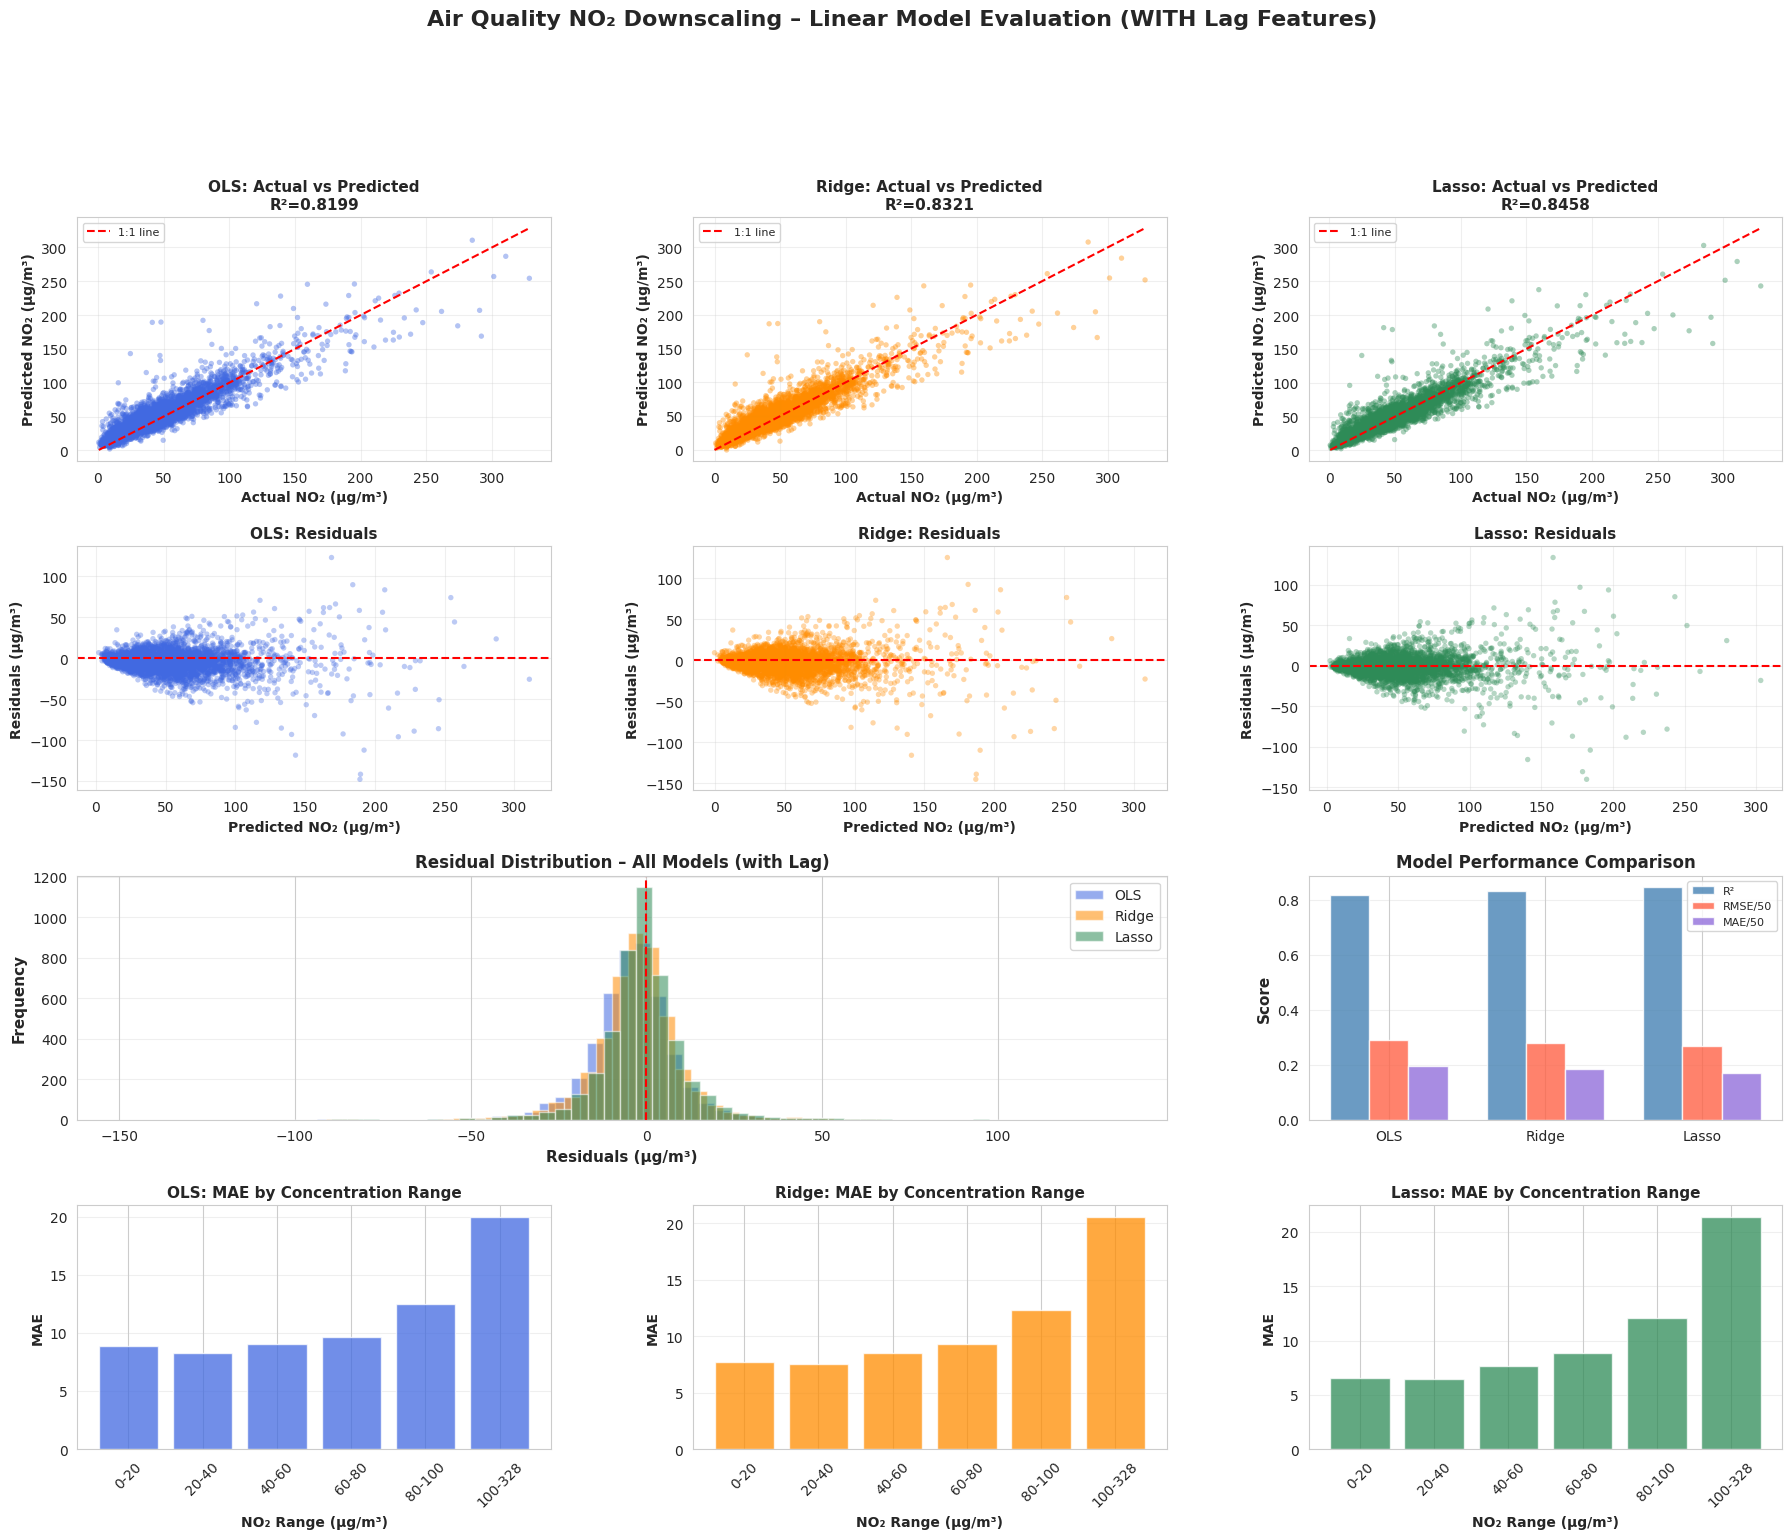


COMPREHENSIVE METRICS SUMMARY

           R2     RMSE     MAE     MBE     NMB  Pearson_r     MAPE     IOA
Model                                                                     
OLS    0.8199  14.5212  9.7973  4.1830  0.0866     0.9144  31.9861  0.9512
Ridge  0.8321  14.0220  9.2087  2.6855  0.0556     0.9160  28.4741  0.9541
Lasso  0.8458  13.4359  8.4440  1.1369  0.0235     0.9203  24.9140  0.9569

✓ Saved: metrics_heatmap_lag.png


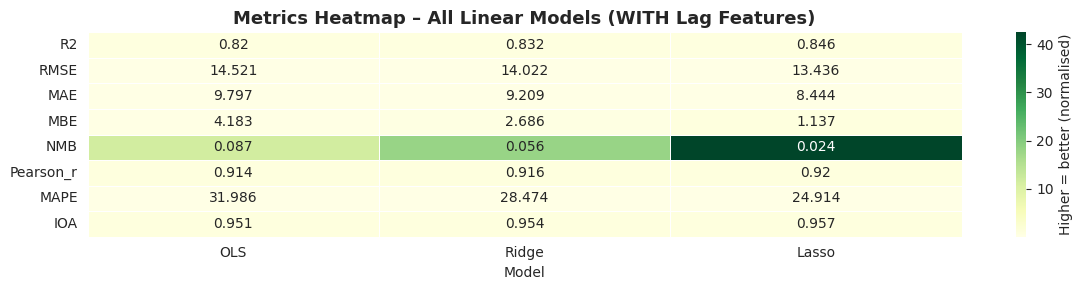

✓ Saved: ols_feature_importance_lag.png


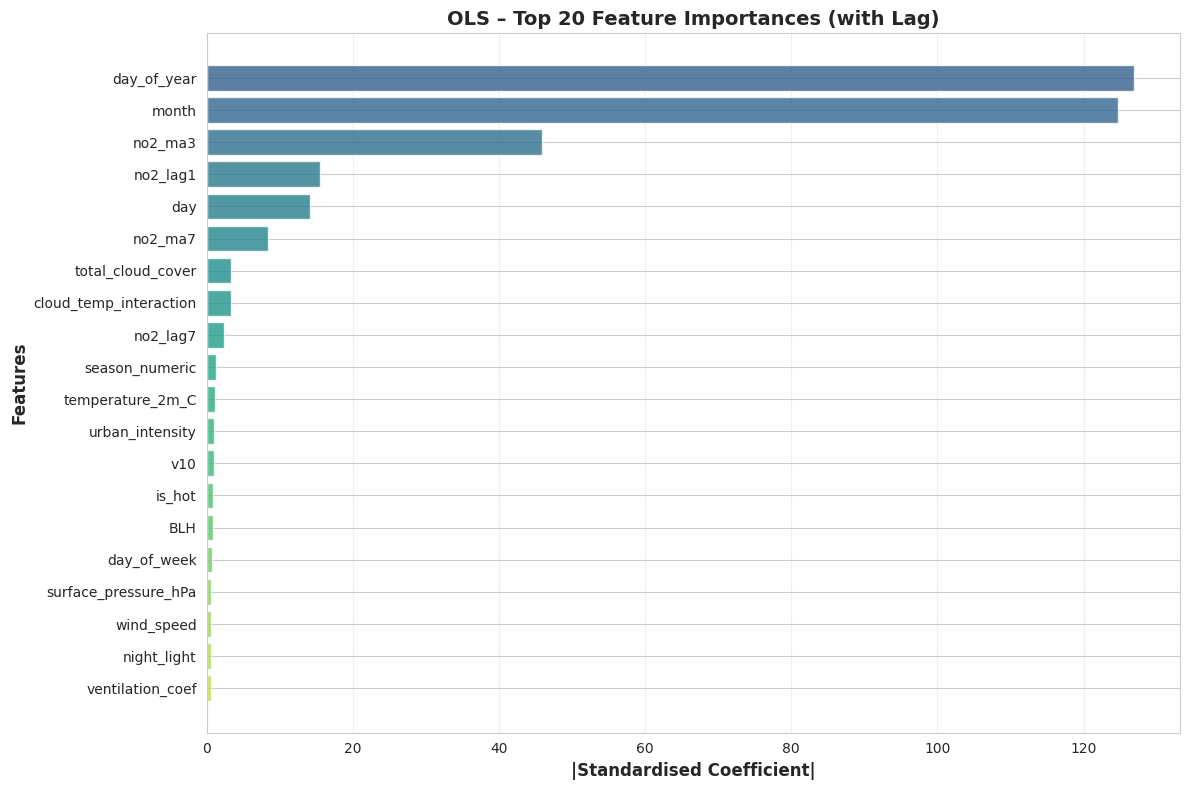


Top 10 features for OLS:
   1. day_of_year                   : +126.8410
   2. month                         : -124.7152
   3. no2_ma3                       : +45.9541
   4. no2_lag1                      : -15.4969
   5. day                           : -14.1793
   6. no2_ma7                       : -8.4750
   7. total_cloud_cover             : -3.3577
   8. cloud_temp_interaction        : +3.3137
   9. no2_lag7                      : +2.4580
  10. season_numeric                : -1.2877
✓ Saved: ridge_feature_importance_lag.png


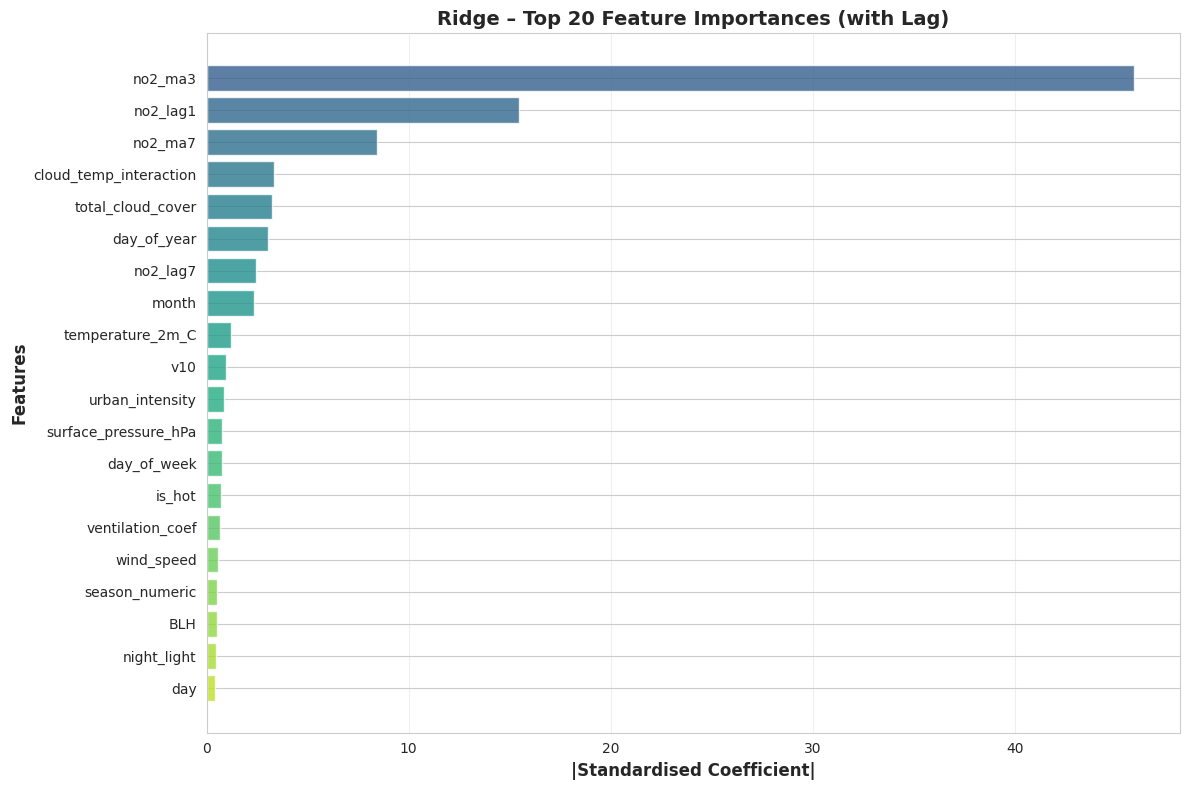


Top 10 features for Ridge:
   1. no2_ma3                       : +45.8595
   2. no2_lag1                      : -15.4450
   3. no2_ma7                       : -8.4443
   4. cloud_temp_interaction        : +3.3423
   5. total_cloud_cover             : -3.2212
   6. day_of_year                   : +3.0362
   7. no2_lag7                      : +2.4586
   8. month                         : -2.3526
   9. temperature_2m_C              : +1.2181
  10. v10                           : -0.9564
✓ Saved: lasso_feature_importance_lag.png


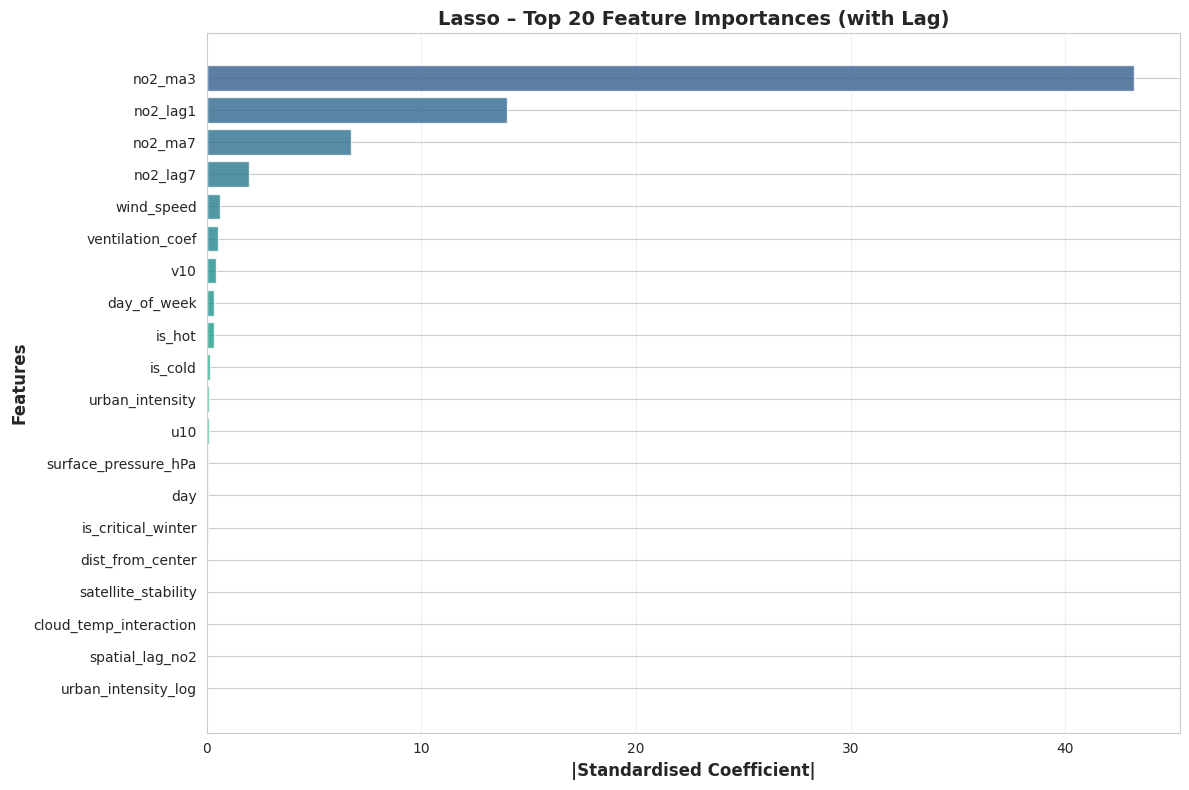


Top 10 features for Lasso:
   1. no2_ma3                       : +43.1753
   2. no2_lag1                      : -13.9732
   3. no2_ma7                       : -6.7349
   4. no2_lag7                      : +1.9996
   5. wind_speed                    : -0.6323
   6. ventilation_coef              : -0.5353
   7. v10                           : -0.4274
   8. day_of_week                   : -0.3547
   9. is_hot                        : +0.3469
  10. is_cold                       : +0.1442

STEP 7: SAVING MODELS TO GOOGLE DRIVE
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT2/trained_models_lag/ols_no2_model_lag.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT2/trained_models_lag/ridge_no2_model_lag.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT2/trained_models_lag/lasso_no2_model_lag.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT2/trained_models_lag/test_station_info_lag.json

✓ All models saved to Google Drive!

  Location: /content/drive/MyDrive/MAJOR_PROJECT2/trained_models_lag

PI

In [ ]:
# ============================================================================
# 9. MAIN EXECUTION PIPELINE
# ============================================================================

def main(filepath):
    print("\n")
    print("╔" + "=" * 78 + "╗")
    print("║" + " " * 78 + "║")
    print("║" + "  AIR QUALITY NO₂ DOWNSCALING MODEL – DELHI".center(78) + "║")
    print("║" + "  OLS | RIDGE | LASSO   ·   WITH Lag Features".center(78) + "║")
    print("║" + "  TEMPORAL + SPATIAL VALIDATION".center(78) + "║")
    print("║" + " " * 78 + "║")
    print("╚" + "=" * 78 + "╝")
    print(f"\nStart time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # ── Pipeline ─────────────────────────────────────────────────────────────
    df = load_and_preprocess_data(filepath)
    df = handle_missing_values(df)         # ML-based gap filling
    df = create_features(df)              # lag features + spatial_lag_no2 included

    (X_train, X_test, y_train, y_test,
     feature_cols, test_station_info,
     df_test_meta) = prepare_train_test_split(df)

    # ── Train models ─────────────────────────────────────────────────────────
    ols_model,   y_pred_ols   = train_ols(X_train, y_train, X_test, y_test)
    ridge_model, y_pred_ridge = train_ridge(X_train, y_train, X_test, y_test)
    lasso_model, y_pred_lasso = train_lasso(X_train, y_train, X_test, y_test)

    # ── Spatial & Temporal R² ─────────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("SPATIAL & TEMPORAL R²")
    print("=" * 80)
    for name, y_pred in [('OLS', y_pred_ols), ('Ridge', y_pred_ridge), ('Lasso', y_pred_lasso)]:
        print(f"\n  ── {name} ──")
        compute_spatial_r2( df_test_meta.reset_index(drop=True), y_pred, station_col='station')
        compute_temporal_r2(df_test_meta.reset_index(drop=True), y_pred, date_col='date')

    # ── Visualisations ───────────────────────────────────────────────────────
    plot_comprehensive_results(y_test, y_pred_ols, y_pred_ridge, y_pred_lasso)

    preds_dict = {'OLS': y_pred_ols, 'Ridge': y_pred_ridge, 'Lasso': y_pred_lasso}
    summary_df = plot_metrics_summary_table(y_test, preds_dict)

    # ── Feature importance for each model ────────────────────────────────────
    for name, mdl in [('OLS', ols_model), ('Ridge', ridge_model), ('Lasso', lasso_model)]:
        plot_feature_importance_linear(mdl, feature_cols, model_name=name)

    # ── Save ─────────────────────────────────────────────────────────────────
    save_models(ols_model, ridge_model, lasso_model, test_station_info)

    # ── Final summary ─────────────────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("PIPELINE COMPLETED SUCCESSFULLY! 🎉")
    print("=" * 80)
    print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("\n✓ Models:       OLS | Ridge | Lasso")
    print("✓ Gap filling:  ML-based (Ridge auxiliary model – no mean imputation)")
    print("✓ Spatial lag:  spatial_lag_no2 feature added")
    print("✓ Lag features: INCLUDED (no2_lag1, no2_lag7, no2_ma3, no2_ma7)")
    print("✓ Metrics:      R², RMSE, MAE, MBE, NMB, Pearson r, MAPE, IOA,")
    print("                Spatial R², Temporal R²")
    print("✓ Visualisations and models saved")

    best_model = max(preds_dict, key=lambda n: r2_score(y_test, preds_dict[n]))
    print(f"\n  → Best model by R²: {best_model}")

    print("\n📍 Test Stations (never seen during training):")
    for s in test_station_info['test_stations']:
        print(f"   • {s}")

    return ols_model, ridge_model, lasso_model, feature_cols, \
           X_train, X_test, y_train, y_test, test_station_info


# ── RUN ────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    filepath = '/content/drive/MyDrive/MAJOR_PROJECT2/MASTERDATASET_39.csv'
    ols_model, ridge_model, lasso_model, features, \
    X_train, X_test, y_train, y_test, test_station_info = main(filepath)

In [ ]:
# ============================================================================
# 10. FISHNET PREDICTION PIPELINE  (with lag feature reconstruction)
# ============================================================================

import pandas as pd
import numpy as np
import pickle

FISHNET_PATH = "/content/drive/MyDrive/MAJOR_PROJECT2/Delhi_500m_ML_Ready_2024.csv"
MODEL_PATH   = "/content/drive/MyDrive/MAJOR_PROJECT2/trained_models_lag/ridge_no2_model_lag.pkl"

df = pd.read_csv(FISHNET_PATH)
df['date'] = pd.to_datetime(df['date'])

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

EXPECTED_FEATURES = list(model.feature_names_in_)
print("Model expects:", len(EXPECTED_FEATURES), "features")
print("Features with lag:", [f for f in EXPECTED_FEATURES if 'lag' in f or 'ma' in f])

Model expects: 36 features
Features with lag: ['satellite_missing_flag', 'no2_lag1', 'no2_lag7', 'no2_ma3', 'no2_ma7', 'spatial_lag_no2']


In [ ]:
# ── Rename if needed ──────────────────────────────────────────────────────────
df = df.rename(columns={'temperature_C': 'temperature_2m_C'})

# ── Temporal features ─────────────────────────────────────────────────────────
df['year']                = df['date'].dt.year
df['month']               = df['date'].dt.month
df['day']                 = df['date'].dt.day
df['day_of_year']         = df['date'].dt.dayofyear
df['day_of_week']         = df['date'].dt.weekday
df['is_weekend']          = (df['day_of_week'] >= 5).astype(int)
df['season_numeric']      = df['month'].map({12:1,1:1,2:1,3:2,4:2,5:2,6:3,7:3,8:3,9:4,10:4,11:4})
df['is_critical_winter']  = df['month'].isin([12,1,2]).astype(int)

# ── Meteorological features ───────────────────────────────────────────────────
df['wind_direction']   = (np.degrees(np.arctan2(df['v10'], df['u10'])) + 360) % 360
df['ventilation_coef'] = df['BLH'] * df['wind_speed']
df['stability_index']  = df['BLH'] / (df['wind_speed'] + 0.1)
df['is_cold'] = (df['temperature_2m_C'] < 15).astype(int)
df['is_hot']  = (df['temperature_2m_C'] > 30).astype(int)

# ── Emission proxies ──────────────────────────────────────────────────────────
df['urban_intensity']     = df['population_density'] * df['night_light']
df['urban_intensity_log'] = np.log1p(df['urban_intensity'])

lat0, lon0 = 28.6139, 77.2090
df['dist_from_center'] = np.sqrt(
    (df['lat'] - lat0)**2 + (df['lon'] - lon0)**2
) * 111

# ── ML-based gap filling (fishnet) ────────────────────────────────────────────
df['satellite_missing_flag'] = df['tropospheric_no2'].isna().astype(int)

proxy_cols_fn = [c for c in df.columns
                 if c not in ['cell_id','date','tropospheric_no2','satellite_missing_flag']
                 and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

obs_mask_fn = df['satellite_missing_flag'] == 0
gap_mask_fn = df['satellite_missing_flag'] == 1

if gap_mask_fn.sum() > 0:
    valid_fn = [
        c for c in proxy_cols_fn
        if df.loc[obs_mask_fn, c].isnull().sum() == 0
        and df.loc[gap_mask_fn, c].isnull().sum() == 0
    ]
    if not valid_fn:
        valid_fn = proxy_cols_fn

    aux_fn = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('ridge',   Ridge(alpha=1.0))
    ])
    aux_fn.fit(df.loc[obs_mask_fn, valid_fn].copy(),
               df.loc[obs_mask_fn, 'tropospheric_no2'])
    df.loc[gap_mask_fn, 'tropospheric_no2'] = np.clip(
        aux_fn.predict(df.loc[gap_mask_fn, valid_fn].copy()), 0, None
    )
    print(f"✅ ML gap-filled {gap_mask_fn.sum():,} missing satellite cells")

# ── Lag features for fishnet ──────────────────────────────────────────────────
# NOTE: For fishnet grids, lag features are built from tropospheric_no2
# as a proxy since groundtruth_no2 is not available at grid level.
print("Computing lag features for fishnet …")
df = df.sort_values(['cell_id', 'date']).reset_index(drop=True)

df['no2_lag1'] = df.groupby('cell_id')['tropospheric_no2'].shift(1)
df['no2_lag7'] = df.groupby('cell_id')['tropospheric_no2'].shift(7)
df['no2_ma3']  = df.groupby('cell_id')['tropospheric_no2'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)
df['no2_ma7']  = df.groupby('cell_id')['tropospheric_no2'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Fill any NaN from lag shift with cell-level mean
for col in ['no2_lag1', 'no2_lag7', 'no2_ma3', 'no2_ma7']:
    df[col] = df.groupby('cell_id')[col].transform(lambda x: x.fillna(x.mean()))
    df[col] = df[col].fillna(df['tropospheric_no2'])  # fallback

print("   ✓ Lag features computed for fishnet")

Computing lag features for fishnet …
   ✓ Lag features computed for fishnet


In [ ]:
# ── Spatial neighbour feature (fishnet) ───────────────────────────────────────
print("Computing spatial_lag_no2 for fishnet …  (may take a moment)")
df = df.sort_values(['date', 'cell_id']).reset_index(drop=True)

cell_coords = df[['cell_id','lat','lon']].drop_duplicates().set_index('cell_id')
daily_cell  = df.groupby(['date','cell_id'])['tropospheric_no2'].mean()

spatial_lag_fn = []
for _, row in df.iterrows():
    dist = np.sqrt(
        (cell_coords['lat'] - row['lat'])**2 +
        (cell_coords['lon'] - row['lon'])**2
    )
    nbrs = dist[(dist <= 0.005) & (dist.index != row['cell_id'])].index.tolist()
    if nbrs:
        vals = [daily_cell[(row['date'], n)] for n in nbrs
                if (row['date'], n) in daily_cell.index]
        spatial_lag_fn.append(np.mean(vals) if vals else np.nan)
    else:
        spatial_lag_fn.append(np.nan)

df['spatial_lag_no2'] = spatial_lag_fn
df['spatial_lag_no2'] = df.groupby('cell_id')['spatial_lag_no2'].transform(
    lambda x: x.fillna(x.mean())
)
df['spatial_lag_no2'] = df['spatial_lag_no2'].fillna(df['tropospheric_no2'])

# ── Interaction features ──────────────────────────────────────────────────────
df['satellite_stability']    = df['tropospheric_no2'] * df['stability_index']
df['cloud_temp_interaction'] = df['total_cloud_cover'] * (1 / (df['temperature_2m_C'] + 1))

# ── Check & predict ───────────────────────────────────────────────────────────
missing_feats = set(EXPECTED_FEATURES) - set(df.columns)
print("Missing features:", missing_feats)

X_fishnet = df[EXPECTED_FEATURES].fillna(df[EXPECTED_FEATURES].mean())
df['no2_pred_ugm3'] = model.predict(X_fishnet)

print(df[['lat','lon','no2_pred_ugm3','date']].head())

Computing spatial_lag_no2 for fishnet …  (may take a moment)
Missing features: set()
         lat        lon  no2_pred_ugm3       date
0  28.561197  76.837604       6.573312 2024-01-01
1  28.565708  76.837682       6.564964 2024-01-01
2  28.570219  76.837761       6.543704 2024-01-01
3  28.574730  76.837839       6.537277 2024-01-01
4  28.579241  76.837917       6.532944 2024-01-01


In [ ]:
# ── Export GeoTIFF ────────────────────────────────────────────────────────────
import os, rasterio
from rasterio.transform import from_origin
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
).to_crs("EPSG:32643")

PIXEL_SIZE = 500
minx, miny, maxx, maxy = gdf.total_bounds
width     = int((maxx - minx) / PIXEL_SIZE)
height    = int((maxy - miny) / PIXEL_SIZE)
transform = from_origin(minx, maxy, PIXEL_SIZE, PIXEL_SIZE)

# ── Daily GeoTIFFs ────────────────────────────────────────────────────────────
OUT_DIR = "/content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag"
os.makedirs(OUT_DIR, exist_ok=True)

for date, day_df in gdf.groupby('date'):
    raster = np.full((height, width), np.nan, dtype=np.float32)
    for _, row in day_df.iterrows():
        c  = int((row.geometry.x - minx) / PIXEL_SIZE)
        ri = int((maxy - row.geometry.y) / PIXEL_SIZE)
        if 0 <= ri < height and 0 <= c < width:
            raster[ri, c] = row.no2_pred_ugm3

    out_path = f"{OUT_DIR}/NO2_500m_{date.strftime('%Y%m%d')}_lag.tif"
    with rasterio.open(out_path, "w", driver="GTiff",
                       height=height, width=width,
                       count=1, dtype="float32",
                       crs="EPSG:32643", transform=transform,
                       nodata=np.nan) as dst:
        dst.write(raster, 1)
    print(f"✅ Exported {out_path}")

# ── Monthly GeoTIFFs ──────────────────────────────────────────────────────────
OUT_DIR_MONTH = "/content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Monthly_Lag"
os.makedirs(OUT_DIR_MONTH, exist_ok=True)

gdf['month_period'] = gdf['date'].dt.to_period('M')
for month, mdf in gdf.groupby('month_period'):
    raster   = np.full((height, width), np.nan, dtype=np.float32)
    mean_df  = mdf.groupby(['lon','lat'])['no2_pred_ugm3'].mean().reset_index()
    mean_gdf = gpd.GeoDataFrame(
        mean_df, geometry=gpd.points_from_xy(mean_df.lon, mean_df.lat), crs="EPSG:4326"
    ).to_crs("EPSG:32643")

    for _, row in mean_gdf.iterrows():
        c  = int((row.geometry.x - minx) / PIXEL_SIZE)
        ri = int((maxy - row.geometry.y) / PIXEL_SIZE)
        if 0 <= ri < height and 0 <= c < width:
            raster[ri, c] = row.no2_pred_ugm3

    out_path = f"{OUT_DIR_MONTH}/NO2_500m_{month}_lag.tif"
    with rasterio.open(out_path, "w", driver="GTiff",
                       height=height, width=width,
                       count=1, dtype="float32",
                       crs="EPSG:32643", transform=transform,
                       nodata=np.nan) as dst:
        dst.write(raster, 1)
    print(f"📅 Exported monthly {out_path}")

✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240101_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240102_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240103_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240104_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240105_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240106_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240107_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240108_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240109_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2_500m_20240110_lag.tif
✅ Exported /content/drive/MyDrive/MAJOR_PROJECT2/GeoTIFF_Daily_Lag/NO2

In [ ]:
"""
HOW TO USE IN GOOGLE COLAB:
============================

1. Install required packages (run once):
   !pip install scikit-learn pandas numpy matplotlib seaborn scipy rasterio geopandas

2. Mount drive and run:
   filepath = '/content/drive/MyDrive/MAJOR_PROJECT/MASTERDATASET_39.csv'
   ols, ridge, lasso, features, X_train, X_test, y_train, y_test, info = main(filepath)

3. Make predictions on new data:
   new_predictions = ridge.predict(X_new[features])

EXPECTED OUTPUTS:
=================
- model_evaluation_comprehensive_lag.png  (actual vs predicted, residuals, MAE by range)
- metrics_heatmap_lag.png                 (all 8 metrics across 3 models)
- ols_feature_importance_lag.png
- ridge_feature_importance_lag.png
- lasso_feature_importance_lag.png
- ols_no2_model_lag.pkl
- ridge_no2_model_lag.pkl
- lasso_no2_model_lag.pkl
- test_station_info_lag.json
- GeoTIFF_Daily_Lag/   (daily NO2 rasters at 500m)
- GeoTIFF_Monthly_Lag/ (monthly mean NO2 rasters at 500m)

KEY CHANGES FROM withLag ORIGINAL:
====================================
✓ Custom metrics:    Added compute_metrics() with MBE, NMB, Pearson r, MAPE, IOA
✓ Spatial R²:        Added compute_spatial_r2() per station
✓ Temporal R²:       Added compute_temporal_r2() per day
✓ Gap filling:       Mean imputation → ML-based Ridge auxiliary model
✓ Models:            Standalone sklearn → sklearn Pipeline (scaler inside)
✓ Feature eng:       spatial_lag_no2 feature ADDED (neighbours within 11 km)
✓ Visualisations:    Extended: metrics_heatmap, MAE by concentration range
✓ Feature importance: |standardised coef| horizontal bar chart saved as PNG
✓ GeoTIFF export:    Daily + Monthly rasters (EPSG:32643, 500 m pixel)
✓ Fishnet lag:       no2_lag1/lag7/ma3/ma7 built from tropospheric_no2 proxy
✓ Save dir:          Separate folder trained_models_lag to avoid overwriting
"""

"\nHOW TO USE IN GOOGLE COLAB:\n============================\n\n1. Install required packages (run once):\n   !pip install scikit-learn pandas numpy matplotlib seaborn scipy rasterio geopandas\n\n2. Mount drive and run:\n   filepath = '/content/drive/MyDrive/MAJOR_PROJECT/MASTERDATASET_39.csv'\n   ols, ridge, lasso, features, X_train, X_test, y_train, y_test, info = main(filepath)\n\n3. Make predictions on new data:\n   new_predictions = ridge.predict(X_new[features])\n\nEXPECTED OUTPUTS:\n=================\n- model_evaluation_comprehensive_lag.png  (actual vs predicted, residuals, MAE by range)\n- metrics_heatmap_lag.png                 (all 8 metrics across 3 models)\n- ols_feature_importance_lag.png\n- ridge_feature_importance_lag.png\n- lasso_feature_importance_lag.png\n- ols_no2_model_lag.pkl\n- ridge_no2_model_lag.pkl\n- lasso_no2_model_lag.pkl\n- test_station_info_lag.json\n- GeoTIFF_Daily_Lag/   (daily NO2 rasters at 500m)\n- GeoTIFF_Monthly_Lag/ (monthly mean NO2 rasters at 500